Predicting NBA Player Scoring

Machine-Learning Problem and Dataset

Prediction Question

How accurately can NBA player statistics be used to predict a player's points per game during the 2025-26 NBA season?

Target Variable and Problem Type

The target variable for this project is points per game (points_pg), which represents the average number of points scored by an NBA player per game during the 2025-26 season. 

This is a regression problem because the target variable is continuous and numerical. The goal is to predict a player's points per game using the other player statistics as features. 

Dataset Source and Unit of Analysis 

The dataset used for this project is the **2025-26 NBA Player Season Totals** dataset from [BoxScore Lab](https://www.boxscorelab.com/downloads/). The dataset contains player-level statistics from the 2025-26 NBA season and is based on data from NBA Stats. 

The unit of analysis is an individual NBA player during the 2025-26 season. Each row represents one player and contains that player's season statistics. 

Features 

The dataset contains 32 variables describing NBA player performance during the 2025-26 season. Potential features for predciting points per game include player age, games played, minutes played, field-goal attempts, three-point attempts, free-throw attempts, shooting percentages, assists, rebounds, turnovers, usage rate, true-shooting percentage, and other performance statistics. 

These features provide information about a player's playing time, shooting activity, efficiency, and overall involvement in the game that may help predict points per game. 

Dataset Size and Missing Values 

The dataset contains 582 NBA players and 32 variables from the 2025-26 season. Each of the 582 players appears once in the dataset, and there are no completely duplicated rows. 

Most variables contain no missing values. The only variable with missing data is position, which is missing for 57 players. The target variable, points per game (points_pg), has no missing values. The missing position values will be considered during the data-preparation process before building the machine-learning models.

In [1]:
import pandas as pd

# Load the 2025-26 NBA player dataset
df = pd.read_csv("2025-26-player-season-totals.csv")

# Display the size of the dataset
print("Dataset shape:", df.shape)

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("\nMissing values by column:")
print(df.isnull().sum())

Dataset shape: (582, 32)
Duplicate rows: 0

Missing values by column:
season                   0
player_name              0
team                     0
position                57
age                      0
games_played             0
minutes                  0
points                   0
rebounds                 0
assists                  0
steals                   0
blocks                   0
turnovers                0
field_goals_made         0
field_goal_attempts      0
field_goal_pct           0
three_point_makes        0
three_point_attempts     0
three_point_pct          0
free_throws_made         0
free_throw_attempts      0
free_throw_pct           0
points_pg                0
rebounds_pg              0
assists_pg               0
ts_pct                   0
effective_fg_pct         0
usage_rate               0
ast_pct                  0
reb_pct                  0
tov_pct                  0
net_rating               0
dtype: int64


Why This Problem Matters

Predicting NBA player scoring is an important application of sports analytics because scoring is a major component of evaluating player performance and offensive contribution. NBA teams, coaches, analysts, and other decision-makers can use statistical models to better understand which aspects of a player's performance are associated with higher scoring averages. 

NBA players differ in playing time, shooting volume, efficiency, usage, and other performance characteristics. Machine-learning models can examine these factors together and identify patterns that may not be as apparent when looking at individual statistics separately. In this project, player statistics from the 2025-26 NBA season will be used to predict season points per game and determine which features are most useful for explaining differences in scoring among players. 

Supporting Research 

Previous research demonstrates that statistical and machine-learning methods can be useful for analyzing basketball player performance. Metulini and Le Carre (2020) used Classification and Regression Trees (CART) with basketball data to examine factors affecting shooting performance. Their study included NBA games and demonstrates how statisical learning methods can be applied to understand player scoring and shooting behavior.

Terner and Franks (2021) reviewed statistical methods used to model player and team performance in basketball. Their research describes how basketball analytics can be used for player evaluation, shot modeling, team strategy, and personnel decisions. This supports the broader use of player statistics and statisical modeling to evaluate NBA performance.

More recently, Abu El Afieh (2026) directly examined the prediction of NBA players points per game using machine-learning models, including linear regression and random forest regression. The study identified variables such as field-goal attempts, minutes played, and true-shooting percentage as important predictors of scoring. This research is particularly relevant to this project because similar player statistics and regression methods will be used to predict points per game. 

References

Abu El Afieh, F. (2026). Can a random forest–based machine learning model accurately predict NBA players’ points per game, and does it outperform traditional linear approaches? *The Oxford Journal, 7*(1). https://doi.org/10.65161/rec8hK8awqIUV5H64

Metulini, R., & Le Carre, M. (2020). Measuring sport performances under pressure by classification trees with application to basketball shooting. *Journal of Applied Statistics, 47*(12), 2120–2135. https://doi.org/10.1080/02664763.2019.1704702

Terner, Z., & Franks, A. (2021). Modeling player and team performance in basketball. *Annual Review of Statistics and Its Application, 8*, 1–23. https://doi.org/10.1146/annurev-statistics-040720-015536


Data Preparation

Before building the machine-learning models, the dataset was cleaned and prepared to ensure that the features were appropriate for predicting points per game. The preparation process includes examining missing values, selecting appropriate predictor variables, handling categorical variables when necessary, and preparing numerical features for modeling. 

Handling Missing Values 

An initial examination of the dataset showed that 'position' was the only variable containing missing values, with 57 missing observations out of 582 players. The target variable, 'points_pg', contained no missing values. Before deciding how to handle the missing position values, the distribution of the available position categories was examined.

Because position is the only variable with missing values, players were not removed from the dataset solely because their position was unavailable. Removing these observations would discard 57 players whose numerical performance statistics and target values are still available. Instead, missing values in 'position' were assigned to an 'Unknown' category. This preserves all observations while allowing position to be treated as a categorical feature if it is included in the model. 

Feature Selection

Predictor variables were selected to represent a player's playing time, shooting volume and efficiency, playmaking, ball control, and role. Variables that directly reveal or mathematically determine scoring were excluded to reduce data leakage. In particular, 'points', 'field_goals_made', 'three_point_makes', and 'free_throws_made' were not used as predictors because they are direct measures or components of the scoring outcome. 

The selected predictors are 'age', 'games_played', 'minutes', 'field_goal_attempts', 'field_goal_pct', 'three_point_attempts', 'three_point_pct', 'free_throw_attempts', 'free_throw_pct', 'assists', 'rebounds', 'turnovers', 'usage_rate', 'ts_pct', 'position', and 'team'. The target variable remains 'points_pg'.

Encoding Categorical Variables

The 'position' and 'team' variables are categorical and therefore cannot be entered directly into the regression models as text. One-hot encoding was used to convert these categories into numerical indicator variables. The first category from each variable was dropped to avoid redundant information among the encoded variables, which is particularly useful for linear regression. 

Scaling and Leakage Prevention

The predictor variables are measured on different scales. For example, shooting percentages are represented as proportions, while variables such as minutes, attempts, rebounds, and assists are season totals. Scaling can therefore be useful for models such as linear regression so that numerical features are represented on comparable scales. 

To prevent data leakage, scaling will not be performed on the full dataset before the train-test split. Instead, the scaler will be fit using only the training data and then applied to the testing data. This ensures that information from the test set does not influence the preprocessing of the training data. 

In [2]:
# Examine the position variable and its missing values
print("Missing position values:", df["position"].isnull().sum())

print("\nPosition counts:")
print(df["position"].value_counts(dropna=False))

Missing position values: 57

Position counts:
position
G      212
F      162
C       57
NaN     57
G-F     49
F-C     45
Name: count, dtype: int64


In [3]:
# Replace missing position values with an "Unknown" category
df["position"] = df["position"].fillna("Unknown")

# Verify that missing values have been handled
print("Missing position values after cleaning:", df["position"].isnull().sum())

print("\nUpdated position counts:")
print(df["position"].value_counts())

Missing position values after cleaning: 0

Updated position counts:
position
G          212
F          162
C           57
Unknown     57
G-F         49
F-C         45
Name: count, dtype: int64


In [4]:
# Select predictors and target
features = [
    "age",
    "games_played",
    "minutes",
    "field_goal_attempts",
    "field_goal_pct",
    "three_point_attempts",
    "three_point_pct",
    "free_throw_attempts",
    "free_throw_pct",
    "assists",
    "rebounds",
    "turnovers",
    "usage_rate",
    "ts_pct",
    "position",
    "team"
]

X = df[features]
y = df["points_pg"]

print("Predictor data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nSelected predictors:")
print(X.columns.tolist())

Predictor data shape: (582, 16)
Target data shape: (582,)

Selected predictors:
['age', 'games_played', 'minutes', 'field_goal_attempts', 'field_goal_pct', 'three_point_attempts', 'three_point_pct', 'free_throw_attempts', 'free_throw_pct', 'assists', 'rebounds', 'turnovers', 'usage_rate', 'ts_pct', 'position', 'team']


In [5]:
# One-hot encode the categorical predictors
X_encoded = pd.get_dummies(
    X,
    columns=["position", "team"],
    drop_first=True,
    dtype=int
)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

print("\nFirst 10 encoded column names:")
print(X_encoded.columns.tolist()[:10])

print("\nRemaining missing values:", X_encoded.isnull().sum().sum())

Shape before encoding: (582, 16)
Shape after encoding: (582, 48)

First 10 encoded column names:
['age', 'games_played', 'minutes', 'field_goal_attempts', 'field_goal_pct', 'three_point_attempts', 'three_point_pct', 'free_throw_attempts', 'free_throw_pct', 'assists']

Remaining missing values: 0


Data Understanding and Feature Selection

Before building the prediction models, exploratory data analysis was performed to better understand the distribution and characteristics of the dataset. Summary statistics, visualizations, correlations, and potential outliers were examined to identify patterns that could affect model development and to help justify the final predictor variables. 

Because the target variable is continuous, this project is a regression problem and does not involve class imbalance. Instead, the analysis focuses on the distribution of points per game and its relationships with the potential predictor variables. 

Summary Statistics 

Summary statistics were examined for the target variable and numerical predictors to understand their ranges, averages, variability, and potential extreme values. 

In [6]:
# Summary statistics for the target and numerical predictors
summary_columns = [
    "points_pg",
    "age",
    "games_played",
    "minutes",
    "field_goal_attempts",
    "field_goal_pct",
    "three_point_attempts",
    "three_point_pct",
    "free_throw_attempts",
    "free_throw_pct",
    "assists",
    "rebounds",
    "turnovers",
    "usage_rate",
    "ts_pct"
]

df[summary_columns].describe().round(2)

,points_pg,age,games_played,minutes,field_goal_attempts,field_goal_pct,three_point_attempts,three_point_pct,free_throw_attempts,free_throw_pct,assists,rebounds,turnovers,usage_rate,ts_pct
count,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00,582.00
mean,9.15,26.31,45.79,1019.76,376.56,0.46,156.31,0.31,99.26,0.74,113.03,185.00,58.31,0.18,0.56
std,6.38,4.22,24.94,771.98,341.04,0.10,155.98,0.14,115.03,0.19,121.80,167.26,54.95,0.05,0.10
min,0.00,19.00,1.00,2.67,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00
25%,4.29,23.00,23.00,293.24,91.50,0.42,21.50,0.28,18.00,0.69,21.25,49.00,14.00,0.14,0.53
50%,7.83,25.00,51.00,940.30,292.00,0.46,114.50,0.34,61.00,0.78,78.50,148.50,42.00,0.17,0.57
75%,12.46,28.00,67.75,1609.39,579.25,0.51,245.75,0.38,131.00,0.84,151.75,275.75,85.00,0.21,0.61
max,33.48,41.00,82.00,2953.15,1543.00,0.83,740.00,1.00,645.00,1.00,697.00,892.00,259.00,0.37,0.92


The summary statistics show substantial variation in player performance and playing opportunity. Players averaged 9.15 points per game, with a median of 7.83 and a maximum of 33.84 points per game. Because the mean is higher than the median and the maximum is considerably higher than the upper quartile of 12.46, the target variable may have a right-skewed distribution with a smaller number of high-scoring players. 

Playing opportunity also varies considerably across the dataset. Games played range from 1 to 82, while total minutes range from 2.67 to 2,953.15. Similar variation appears in shooting attempts, assists, rebounds, and turnovers. These differences suggest that playing time and offensive opportunity may be important predictors of scoring. Players with extremely limited playing time may also produce unusual values that should be considered when examining the target distribution and potential outliers. 

Distribution of Points Per Game 

The distribution of the target variable was examined to identify its overall shape, range, and potential extreme values. 

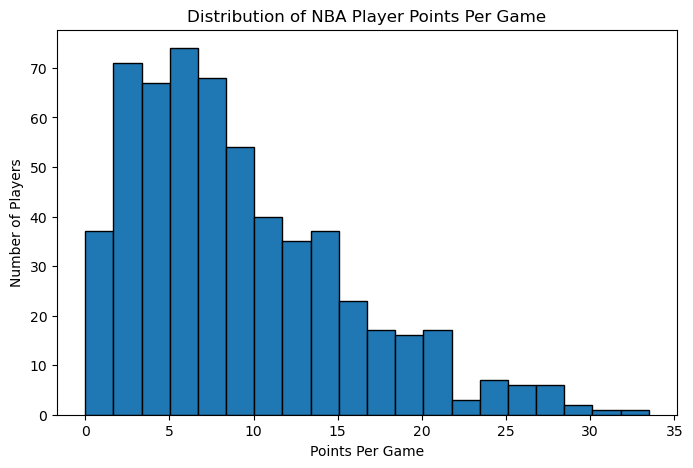

In [7]:
import matplotlib.pyplot as plt

# Plot the distribution of points per game
plt.figure(figsize=(8, 5))
plt.hist(df["points_pg"], bins=20, edgecolor="black")

plt.title("Distribution of NBA Player Points Per Game")
plt.xlabel("Points Per Game")
plt.ylabel("Number of Players")

plt.show()

The histogram shows that points per game has a right-skewed distribution. Most NBA players average between approximately 2 and 12 per game, while fewer players average more than 20 points per game. A small number of players average close to or above 30 points per game, creating a long right tail.

This pattern suggests that the dataset contains considerably more low and moderate scoring players than high scoring players. The high-scoring observations are important to examine because they may influence model performance. However, they should not automatically be removed, since high scoring averages can represent legitimate NBA player performance. 

Potential Outliers 

A boxplot was used to examine potential outliers in the target variable. This helps determine whether unusually high or low scoring averages could affect model development. 

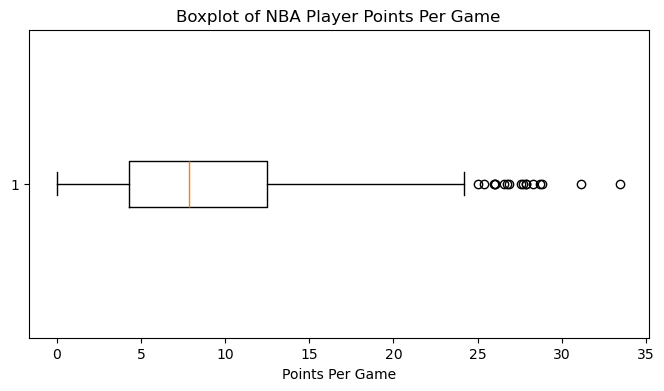

In [8]:
# Boxplot of points per game
plt.figure(figsize=(8, 4))

plt.boxplot(df["points_pg"], vert=False)

plt.title("Boxplot of NBA Player Points Per Game")
plt.xlabel("Points Per Game")

plt.show()

The boxplot identifies several high-scoring players as potential statistical outliers, primarily among players averaging approximately 25 or more points per game. These observations are consistent with legitimate high-scoring NBA players rather than obvious data errors. 

Therefore, these observations were retained in the dataset. Removing them would exclude an important group of players and reduce the model's ability to learn scoring patterns across the full range of NBA player performance. The presence of these high-scoring plaayers will still be considered when evaluating model performance. 

Relationships with Points Per Game

Correlations between the numerical predictor variables and 'points_pg' were examined to identify which features have the strongest linear relationships with player scoring. These relationships help guide feature selection before model development. 

In [9]:
# Calculate correlations between numerical predictors and points per game
numeric_features = [
    "age",
    "games_played",
    "minutes",
    "field_goal_attempts",
    "field_goal_pct",
    "three_point_attempts",
    "three_point_pct",
    "free_throw_attempts",
    "free_throw_pct",
    "assists",
    "rebounds",
    "turnovers",
    "usage_rate",
    "ts_pct"
]

correlations = (
    df[numeric_features + ["points_pg"]]
    .corr()["points_pg"]
    .drop("points_pg")
    .sort_values(ascending=False)
)

correlations.round(3)

field_goal_attempts     0.861
free_throw_attempts     0.849
turnovers               0.796
usage_rate              0.763
minutes                 0.718
assists                 0.712
three_point_attempts    0.677
rebounds                0.598
games_played            0.437
free_throw_pct          0.308
ts_pct                  0.286
three_point_pct         0.270
field_goal_pct          0.189
age                     0.120
Name: points_pg, dtype: float64

The correlation analysis shows that several measures of offensive opportunity have strong positive relationships with points per game, Field-goal attempts had the strongest correlation with scoring ('r = 0.861'), followed by free-throw attempts ('r = 0.849'), turnovers ('r = 0.796'), usage rate ('r = 0.763), minutes ('r = 0.718), and assists ('r = 0.712'). Three-point attempts also showed a moderately strong positive relationship ('r = 0.677'). 

In comparison, shooting percentages generally had weaker linear relationships with points per game. Field-goal percentage had a correlation of only '0.189', while three-point percentage ('0.270') and true-shooting percentage ('0.286') were also relatively weak. This suggests that scoring differences among players may be more strongly associated with offensive opportunity and shot volume than shooting efficiency alone. 

The strong positive relationship between turnovers and scoring should not be interpreted as turnovers causing playes to score more. High-usage players typically handle the ball and participate in more offensive possessions, which can result in both more scoring opportunites and more turnovers. Correlation alone does not establish causation. 

Relationships Among Predictor Variables 

The relationships among numerical predictors were also examined before modeling. Highly correlated predictors may contain overlapped information, which is especially important to consider for linear regression. A correlation matrix was used to identify potential redundancy among the selected numerical features. 

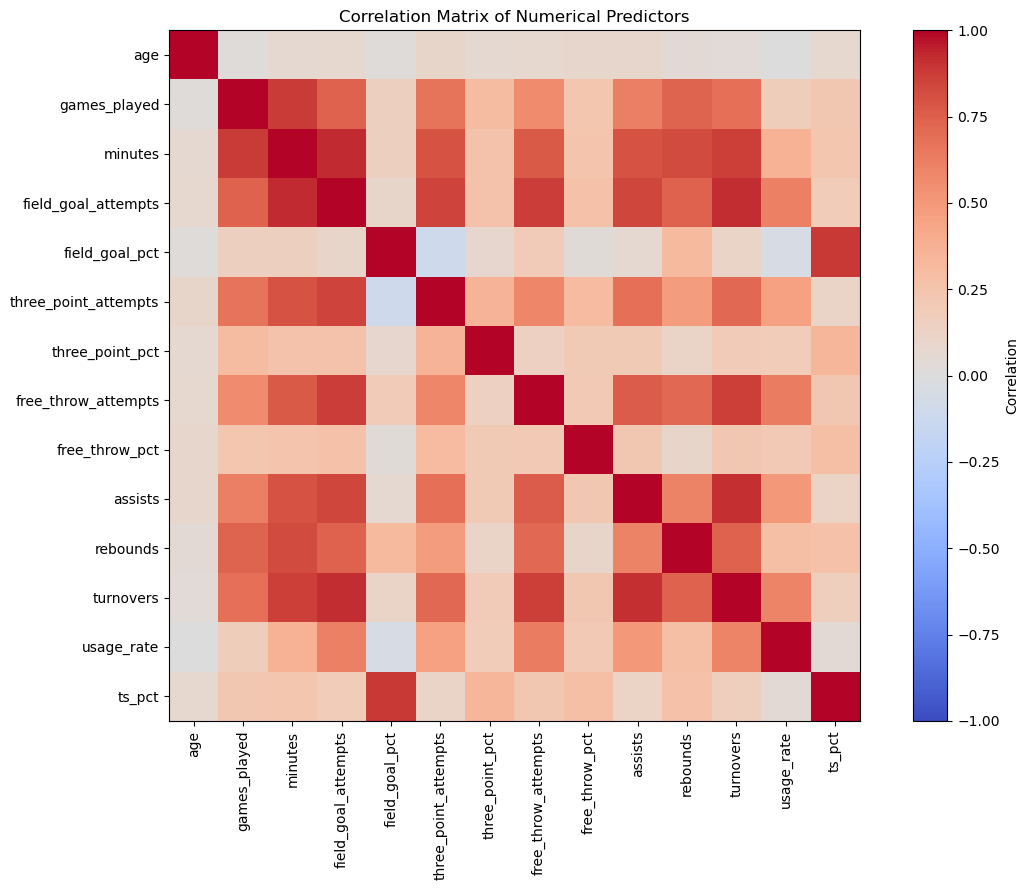

[('games_played', 'minutes', np.float64(0.88)),
 ('minutes', 'field_goal_attempts', np.float64(0.929)),
 ('minutes', 'three_point_attempts', np.float64(0.804)),
 ('minutes', 'assists', np.float64(0.802)),
 ('minutes', 'rebounds', np.float64(0.82)),
 ('minutes', 'turnovers', np.float64(0.863)),
 ('field_goal_attempts', 'three_point_attempts', np.float64(0.847)),
 ('field_goal_attempts', 'free_throw_attempts', np.float64(0.87)),
 ('field_goal_attempts', 'assists', np.float64(0.841)),
 ('field_goal_attempts', 'turnovers', np.float64(0.917)),
 ('field_goal_pct', 'ts_pct', np.float64(0.887)),
 ('free_throw_attempts', 'turnovers', np.float64(0.865)),
 ('assists', 'turnovers', np.float64(0.907))]

In [10]:
# Correlation matrix among numerical predictors
predictor_corr = df[numeric_features].corr()

plt.figure(figsize=(12, 9))

plt.imshow(predictor_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=90
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.title("Correlation Matrix of Numerical Predictors")
plt.tight_layout()
plt.show()

# Display highly correlated predictor pairs
high_corr_pairs = []

for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):
        corr_value = predictor_corr.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append(
                (
                    numeric_features[i],
                    numeric_features[j],
                    round(corr_value, 3)
                )
            )

high_corr_pairs

The predictor correlation analysis identified several strong relationships among the numerical features. For example, minutes and field-goal attempts were highly correlated ('r = 0.929'), field-goal attempts and turnovers were highly correlated ('r = 0.917'), and assists and turnovers were also highly correlated ('r = 0.907'). Minutes were strongly related to several season-total statistics, including assists, rebounds, turnovers, and shot attempts. 

These relationships indicate that several predictors contain overlapping information. This is particularly relevant because many of these variables are season totals, while the target variable is points per game. Players who participate in more games or minutes naturally accumulate larger season totals. Therefore, the feature set should be refined before modeling so that predictors better represent per-game player performance and unnecessary redundancy is reduced. 

Creating Per-Game Features 

Because the target variable measures scoring on a per-game basis, several season-total predictors were converted to per-game measures. This reduces the influence of differences in the number of games played and makes the predictors more directly comparable with the target. Per-game measures were created for minutes, field-goal attempts, three-point attempts, free-throw attempts, and turnovers. The dataset's existing per-game variables for assists and rebounds were also used. 

In [11]:
# Create per-game predictor variables
df["minutes_pg"] = df["minutes"] / df["games_played"]
df["field_goal_attempts_pg"] = df["field_goal_attempts"] / df["games_played"]
df["three_point_attempts_pg"] = df["three_point_attempts"] / df["games_played"]
df["free_throw_attempts_pg"] = df["free_throw_attempts"] / df["games_played"]
df["turnovers_pg"] = df["turnovers"] / df["games_played"]

# Preview the new per-game features
df[
    [
        "points_pg",
        "minutes_pg",
        "field_goal_attempts_pg",
        "three_point_attempts_pg",
        "free_throw_attempts_pg",
        "assists_pg",
        "rebounds_pg",
        "turnovers_pg"
    ]
].head()

,points_pg,minutes_pg,field_goal_attempts_pg,three_point_attempts_pg,free_throw_attempts_pg,assists_pg,rebounds_pg,turnovers_pg
0,18.2658,37.381646,13.215190,1.468354,4.936709,5.3165,7.7722,2.405063
1,25.9744,36.407991,17.641026,5.769231,5.987179,4.7692,5.4615,3.153846
2,20.0854,33.610305,14.695122,5.207317,4.219512,4.1220,4.1220,2.000000
3,13.4146,33.307765,10.865854,7.219512,1.670732,2.4512,5.1341,1.756098
4,15.7792,35.134610,12.662338,6.337662,2.714286,1.8571,6.8701,1.363636


In [12]:
# Examine correlations between per-game predictors and points per game
per_game_features = [
    "minutes_pg",
    "field_goal_attempts_pg",
    "three_point_attempts_pg",
    "free_throw_attempts_pg",
    "assists_pg",
    "rebounds_pg",
    "turnovers_pg",
    "usage_rate",
    "field_goal_pct",
    "three_point_pct",
    "free_throw_pct"
]

per_game_correlations = (
    df[per_game_features + ["points_pg"]]
    .corr()["points_pg"]
    .drop("points_pg")
    .sort_values(ascending=False)
)

per_game_correlations.round(3)

field_goal_attempts_pg     0.981
free_throw_attempts_pg     0.890
minutes_pg                 0.872
turnovers_pg               0.833
usage_rate                 0.763
assists_pg                 0.736
three_point_attempts_pg    0.715
rebounds_pg                0.604
free_throw_pct             0.308
three_point_pct            0.270
field_goal_pct             0.189
Name: points_pg, dtype: float64

The per-game features show stronger and more directly interpretable relationships with points per game than many of the original season-total variables. Field-goal attempts per game had the strongest relationship with scoring ('r = 0.981'), followed by free-throw attempts per game ('r = 0.890') and minutes per game ('r = 0.872'). Turnovers per game ('r = 0.833') and usage rate ('r = 0.763') were also strongly associated with scoring. 

Assists per game ('r = 0.736'), three-point attempts per game ('r = 0.715'), and rebounds per game ('r = 0.604') showed moderate to strong positive relationships with points per game. Shooting percentages had weaker individual linear relationships with scoring, including free-throw percentage ('r = 0.308'), three-point percentage ('r = 0.270'), and field-goal percentage ('r = 0.189'). 

These results support using per-game measures rather than season totals for the final models. Since the target is also measured per game, these features better represent a player's typical game-level performance and reduce the influence of differences in the number of games played. 

Final Feature Selection

Based on the exploratory analysis, the predictor set was refined before model development. Season-total measures such as total minutes, field-goal attempts, three-point attempts, free-throw attempts, assists, rebounds, and turnovers were replaced with per-game measures. This makes the predictors more consistent with the per-game target and reduces the influence of differences in games played. 

The final numerical predictors include 'age', 'minutes_pg', 'field_goal_attempts_pg', 'field_goal_pct', 'three_point_attempts_pg', 'three_point_pct', 'free_throw_attempts_pg', 'free_throw_pct', 'assists_pg', 'rebounds_pg', 'turnovers_pg', and 'usage_rate'. Player 'position' is also retained as a categorical predictor because different positions may reflect different offensive roles and playing styles. 

The 'ts_pct' variable was excluded from the final feature set because points scored are used in the calculation of true-shooting percentage. Including it could introduce target leakage when predicting 'points_pg'. The 'team' variable was also excluded from the final model because the goal is to predict scoring from individual player characteristics rather than create a large number of team-specific indicator variables. These decisions produce a more focused feature set based on the patterns identified during exploratory analysis. 

In [13]:
# Define the final predictor set based on exploratory analysis
final_features = [
    "age",
    "minutes_pg",
    "field_goal_attempts_pg",
    "field_goal_pct",
    "three_point_attempts_pg",
    "three_point_pct",
    "free_throw_attempts_pg",
    "free_throw_pct",
    "assists_pg",
    "rebounds_pg",
    "turnovers_pg",
    "usage_rate",
    "position"
]

X_final = df[final_features]
y = df["points_pg"]

# One-hot encode the categorical position variable
X_final = pd.get_dummies(
    X_final,
    columns=["position"],
    drop_first=True,
    dtype=int
)

print("Final predictor data shape:", X_final.shape)
print("Target data shape:", y.shape)

print("\nFinal model predictors:")
print(X_final.columns.tolist())

print("\nRemaining missing values:", X_final.isnull().sum().sum())

Final predictor data shape: (582, 17)
Target data shape: (582,)

Final model predictors:
['age', 'minutes_pg', 'field_goal_attempts_pg', 'field_goal_pct', 'three_point_attempts_pg', 'three_point_pct', 'free_throw_attempts_pg', 'free_throw_pct', 'assists_pg', 'rebounds_pg', 'turnovers_pg', 'usage_rate', 'position_F', 'position_F-C', 'position_G', 'position_G-F', 'position_Unknown']

Remaining missing values: 0


Training and Testing Strategy 

The dataset was divided into seperate training and testing sets before model development. An 80/20 train-test split was used, with 80% of the observations used to train the models and the remaining 20% reserved for final evaluation. This approach provides the models with most of the available data for learning while maintaining a seperate set of unseen players for evaluating predictive performance. 

A fixed 'random_state' was used to make the split reproducible. Because this is a regression problem with a continuous target variable, the data were randomly divided rather than stratified by class. 

To prevent data leakage, the testing data will not be used to fit the models or determine preprocessing parameters. Any preprocessing that learns information from the data, such as feature scaling, will be fit using only the training set and then applied to the testing set. The test set will remain seperate until model evaluation. 

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training predictor shape: (465, 17)
Testing predictor shape: (117, 17)
Training target shape: (465,)
Testing target shape: (117,)


The 80/20 split resulted in 465 players in the training set and 117 players in the testing set. All 17 predictor columns are present in both sets, and the corresponding target variables contain the same number of observations. 

The training set will be used for model fitting and any preproprocessing that requires learning parameters from the data. The testing set will remain unseen during training and will only be used to evaluate how well the final models generalize to new observations. 

Baseline Performance 

Before training machine-learning models, a baseline model was established to provide a simple benchmark for comparison. Because this is a regression problem, the baseline predicts the mean points per game from the training set for every player in the testing set. 

This baseline does not use any predictor variables or learn relationships between player statistics and scoring. Therefore, the trained machine-learning models should outperform the baseline if they successfully learn useful patterns in the data. 

In [15]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and fit a baseline model that predicts the training-set mean
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

# Make baseline predictions on the test set
baseline_predictions = baseline_model.predict(X_test)

# Calculate baseline evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline prediction:", round(float(baseline_model.constant_.item()), 3))
print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R²:", round(baseline_r2, 3))

Baseline prediction: 9.309
Baseline MAE: 4.63
Baseline RMSE: 5.653
Baseline R²: -0.019


Baseline Results 

The baseline model predicted approximately **9.309 points per game** for every player in the testing set, which represents the mean points per game of the training data. The baseline produced a **mean absolute error (MAE) of 4.630 points**, meaning its predictions differed from players actual scoring averages by approximately 4.63 points per game on average. 

The baseline also produced a **root mean squared error (RMSE) of 5.653 points**. Because RMSE gives greater weight to larger prediction errors, its higher value indicates that some players scoring averages differed substantially from the constant baseline prediction. 

The baseline **R^2 was -0.019**, indicating that simply predicting the training-set mean does not explain variation in the test-set scoring averages. These results provide a benchmark for evaluating the trained machine-learning models. A successful model should produce lower MAE and RMSE values and a higher R^2 value than this baseline. 

Model Development and Comparison

Two regression models were selected and trained to predict NBA player points per game. **Linear Regression** and **Random Forest Regression**

Linear Regression was selected as a relatively simple and interpretable model that estimates linear relationships between the predictor variables and points per game. Random Forest Regression was selected as a more flexible model that can capture nonlinear relationships and interactions among player statistics. 

Using models with different levels of complexity allows their predictive performance to be compared and helps determine whether a nonlinear approach provides an advantage over a traditional linear model. Both models will be evaluated using the same MAE, RMSE, and R^2 metrics used for the baseline model. 

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Create the scaler
scaler = StandardScaler()

# Fit the scaler only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the training-set scaling to the test data
X_test_scaled = scaler.transform(X_test)

# Create and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
linear_predictions = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [17]:
# Evaluate the Linear Regression model
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression MAE:", round(linear_mae, 3))
print("Linear Regression RMSE:", round(linear_rmse, 3))
print("Linear Regression R²:", round(linear_r2, 3))

Linear Regression MAE: 0.408
Linear Regression RMSE: 0.557
Linear Regression R²: 0.99


Linear Regression Results

The Linear Regression model substantially outperformed the baseline. It produced a mean absolute error (MAE) of **0.408 points per game**, compared with **4.630** for the baseline, and a root mean squared error (RMSE) of **0.557**, compared with **5.653** for the baseline. 

The model achieved an **R^2 of 0.990**, indicating that approximately 99% of the variation in points per game within the testing data was explained by the predictors included in the model. These results indicate that the selected player statistics have a very strong relationship with scoring. 

The particularly strong performance is consistent with the exploratory analysis, which showed that variables such as field-goal attempts per game, free-throw attempts per game, and minutes per game were strongly associated with points per game. The model's performance will next be compared with a Random Forest Regression model to determine whether a more flexible nonlinear model provides additional predictive benefit. 

Random Forest Regression

Random Forest Regression was used as the second machine-learning model. Unlike Linear Regression, Random Forest can capture nonlinear relationships and interactions among predictor variables by combining predictions from many decision trees. Feature scaling is not required for this tree-based model, so the original training and testing predictor values were used. 

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Regression model
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model using the training data
random_forest_model.fit(X_train, y_train)

# Make predictions on the test data
random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [19]:
# Evaluate the Random Forest Regression model
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(
    mean_squared_error(y_test, random_forest_predictions)
)
random_forest_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest MAE:", round(random_forest_mae, 3))
print("Random Forest RMSE:", round(random_forest_rmse, 3))
print("Random Forest R²:", round(random_forest_r2, 3))

Random Forest MAE: 0.59
Random Forest RMSE: 0.825
Random Forest R²: 0.978


Random Forest Results and Model Comparison

The Random Forest Regression model also performed substantially better than the baseline. It achieved a mean absolute error (MAE) of **0.590 points per game**, a root mean squared error (RMSE) of **0.825 points**, and an **R^2 of 0.978**. This indicates that the Random Forest model explained approximately 97.8% of the variation in points per game within the testing data. 

Although both trained models performed well, Linear Regression produced the strongest overall results. Linear Regression achieved a lower MAE (**0.408 vs. 0.590**), a lower RMSE (**0.557 vs 0.825**), and a higher R^2 (**0.990 vs 0.978**) than Random Forest Regression. 

These results suggest that the relationships between the selected player statistics and points per game can be modeled very effectively using a linear approach. The additional complexity of Random Forest Regression did not improve predictive performance on the testing data. Based on these evaluation metrics, **Linear Regression is the better-performing model of the two models tested**.

In [20]:
# Compare baseline and trained model performance
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        random_forest_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        random_forest_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        random_forest_r2
    ]
})

model_comparison.round(3)

,Model,MAE,RMSE,R²
0,Baseline,4.630,5.653,-0.019
1,Linear Regression,0.408,0.557,0.990
2,Random Forest Regression,0.590,0.825,0.978


Model Evaluation

The models were evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R^2**. These metrics are appropriate for this project because the target variable, points per game, is continuous. 

**Mean Absolute Error (MAE) measures the average absolute difference between the predicted and actual points-per-game values. Because MAE is expressed in the same units as the target variable, it can be interpreted directly as the average number of points per game by which the model's predictions are incorrect. Lower MAE values indicate better predictive performance. 

**Root Mean Squared Error (RMSE)** measures prediction error while giving greater weight to larger errors. Like MAE, RMSE is expressed in points per game, but it penalizes large prediction errors more strongly. Lower RMSE values indicate better predictive performance. 

**R^2** measures the proportion of varitation in points per game explained by the model. Higher R^2 values indicate that the model explains more of the variation in the target variable. An R^2 closer to 1 represents stronger predictive performance.

Evaluation Results 

The baseline model produced an MAE of **4.630**, an RMSE of **5.653**, and an R^2 of **-0.019**. Both trained machine-learned models substantially improved upon this baseline. 

Linear Regression achieved an MAE of **0.408**, an RMSE of **0.557**, and an R^2 of **0.990**. This means that its predictions differed from actual player scoring averages by approximately 0.41 points per game on average, while the model explained approximately 99% of the variation in points per game in the testing data. 

Random Forest Regression achieved an MAE of **0.590**, an RMSE of **0.825**, and an R^2 of **0.978**. Although these results also demonstrate strong predictive performance, Random Forest produced larger prediction errors and explained slightly less variation in scoring than Linear Regression. 

Based on all three evaluation metrics, **Linear Regression was selected as the best-performing model**. It had the lowest MAE and RMSE and the highest R^2 of the models tested. The results also show that the additional complexity of Random Forest did not improve prediction accuracy for this dataset. 

Model Interpretation 

Because Linear Regression produced the strongest predictive performance, it was selected for further interpretation. Linear Regression coefficients can be examined to understand how each predictor contributes to the model's predictions. 

The numerical predictors were standardized before modeling training, so their coefficient magnitudes can help identify which variables have stronger relationships with predicted points per game. Positive coefficients indicate that higher values of a predictor are associated with higher predicted scoring, while negative coefficients indicate an association with lower predicted scoring when the other predictors are held constant. 

In [21]:
# Examine Linear Regression coefficients
linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

# Add absolute coefficient values for ranking
linear_coefficients["Absolute Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

# Sort from strongest to weakest coefficient
linear_coefficients = linear_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

linear_coefficients.round(3)

,Feature,Coefficient,Absolute Coefficient
2,field_goal_attempts_pg,4.869,4.869
6,free_throw_attempts_pg,1.743,1.743
3,field_goal_pct,0.548,0.548
4,three_point_attempts_pg,0.406,0.406
10,turnovers_pg,-0.281,0.281
1,minutes_pg,-0.225,0.225
5,three_point_pct,0.159,0.159
9,rebounds_pg,0.138,0.138
8,assists_pg,0.088,0.088
11,usage_rate,-0.077,0.077


Interpretation of Model Coefficients 

The Linear Regression coefficients show that shooting volume was the strongest contributor to predicted points per game. 'field_goal_attempts_pg' had the largest positive standardized coefficient at **4.869**, followed by 'free_throw_attempts_pg' at **1.743**. This indicates that, after accounting for the other predictors in the model, players who attempt more field goals and free throws per game tend to receive substantially higher predicted scoring averages. 

Shooting efficiency also contributed positively to predicted scoring. 'field_goal_pct' had a coefficient of **0.548**, while 'three_point_attempts_pg' had a coefficient of **0.406** and 'three_point_pct' had a coefficient of **0.159**. These results suggest that scoring predictions depend primarily on shot volume, while shooting efficiency provides additional predictive information. 

Some variables, including 'minutes_pg' (-0.225), 'turnovers_pg' (-0.281), and 'usage_rate' (-0.077), had negative coefficients despite showing positive individual correlations with points per game during exploratory analysis. This difference occurs because the regression coefficients represent each variable's relationship with scoring while holding the other predictors constant. Several measures of playing time and offensive involvement are related to one another, so their coefficients should be interpreted within the full multivariable model rather than as isolated relationships. 

The position indicator variables had relatively small coefficients compared with the primary numerical predictors. This suggests that after accounting for a player's shooting volume, efficiency, and other performance statistics, position contributed relatively little additional information to the model's scoring predictions. 

In [22]:
# Compare actual and predicted points per game
prediction_comparison = pd.DataFrame({
    "Actual PPG": y_test,
    "Predicted PPG": linear_predictions
})

prediction_comparison["Prediction Error"] = (
    prediction_comparison["Actual PPG"]
    - prediction_comparison["Predicted PPG"]
)

prediction_comparison["Absolute Error"] = (
    prediction_comparison["Prediction Error"].abs()
)

prediction_comparison.round(3).head(10)

,Actual PPG,Predicted PPG,Prediction Error,Absolute Error
577,2.000,2.321,-0.321,0.321
280,10.000,9.441,0.559,0.559
104,6.646,7.181,-0.534,0.534
447,2.938,2.837,0.101,0.101
434,2.209,2.039,0.170,0.170
291,17.061,17.312,-0.251,0.251
405,2.354,2.351,0.004,0.004
182,6.529,6.216,0.314,0.314
353,5.717,5.974,-0.257,0.257
368,3.667,3.825,-0.159,0.159


Example Predictions

Examining individual predictions provides additional insight into the behavior of the Linear Regression model. Across the example test observations, predicted points per game were generally close to the actual scoring averages. 

For example, one player who averaged **17.061 points per game** was predicted to average **17.312**, resulting in an absolute error of only **0.251 points per game**. Another player who averaged **2.354 points per game** received a prediction of **2.351**, an absolute error of approximately **0.004 points per game**. 

The model did not consistently predict above or below the actual values. Some observations were slightly overpredicted, while others were slightly underpredicted. Among these ten examples, the largest absolute prediction error was approximately **0.559 points per game**. This pattern is consistent with the model's overall MAE of **0.408**, showing that the Linear Regression model generally produced predictions that there were close to players actual scoring averages. 

Combined with the coefficient analysis, these example predictions demonstrate that the model relies heavily on shooting opportunity, particularly field-goal and free-throw attempts per game, while producing accurate scoring predictions across different levels of player scoring. 

Ethics and Limitations 

Although the models produced strong predictive results, several limitations should be considered when interpreting the findings. 

One important limitation is that the dataset contains statistics from only the **2025-26 NBA season**. The relationships identified by the models may not remain identical across different seasons because player roles, team strategies, league trends, injuries, and playing styles can change over time. Therefore, the model's performance on this dataset does not guarantee the same level of accuracy when predicting scoring in future NBA seasons. 

Another limitation is that many of the predictors are closely connected to how points per game are produced. In particular, field-goal attempts, free-throw attempts, and shooting percentages contain substantial information about a player's scoring opportunites and efficiency. This helps explain the extremely high predictive performance of the linear regression model. As a result, the model is better interpreted as predicting or estimating scoring from a player's observed season statistics rather than forecasting a player's scoring before those statistics are known. 

Possible sources of bias also exist within the dataset. Players receive different amounts of playing time and offensive opportunities depending on factors such as team role, coaching decisions, injuries, roster construction, and player experience. These factors may influence both the predictor variables and points per game but are not fully represented by the model. The dataset also contains 57 players whose positions were originally missing and were categorized as 'Unknown', which may reduce the usefulness of position for those observations. 

Incorrect predictions could have consequences if the model were used for real-world basketball decisions. For example, relying too heavily on predicted scoring could contribute to inaccurate evaluations of players in areas such as roster decisions, playing time, scouting, or contract discussions. A player's value also extends beyond scoring and includes factors such as defense, leadership, decision-making, and team fit that are not fully represented in this model. 

For these reasons, the model should be used as a **supporting analytical tool rather than as the sole basis for basketball decisions**. Its predictions should be considered alongside additional statistics, contextual information, scouting observations, and basketball expertise. Future versions of the project could also use data from multiple NBA seasons, incorporate additional contextual variables, and evaluate performance on future-season data to determine how well the model generalizes beyond the 2025-26 season.

Code and AI Transparency 

Code Availability 

The complete Python code and Jupyter Notebook used for this project are available through my GitHub portfolio repository. 

**GitHub Repository.** []

Data Source 

The dataset used in this project is the **2025-26 NBA Player Season Totals** dataset from [BoxScore Lab](### Data Source

The dataset used in this project is the **2025–26 NBA Player Season Totals** dataset from [BoxScore Lab](https://www.boxscorelab.com/downloads/). The dataset contains player-level statistics from the 2025-26 NBA season and is based on data from NBA Stats. 

Generative AI Disclosure

Generative AI was used as a support tool during this project. It was used to help clarify assignment requirements, troubleshoot coding errors, suggest approaches for data cleaning, and improve initially written explanations.
